In [16]:
import pandas as pd
from scipy.stats import norm
from scipy.optimize import brentq

from data.loader import load_underlying_data, load_option_data
from option_builder.option_processing import OptionDatabase
from backtest_engine.engine import BacktestEngine
from portfolio.portfolio import Portfolio

# empty template
from strategy.template_option_strategy import TemplateOptionStrategy
from strategy.template_underlying_strategy import TemplateUnderlyingStrategy

# hedging strategy
from strategy.underlying_delta_hedging_strategy import UnderlyingDeltaHedgingStrategy

from strategy.synthetic_futures_basis_arbitrage_strategy import SyntheticFuturesBasisArbitrageStrategy
from strategy.synthetic_futures_basis_arbitrage_second_strategy import SyntheticFuturesBasisArbitrageSecondStrategy

from strategy.synthetic_futures_basis_arbitrage_strategy_ver2 import SyntheticFuturesBasisArbitrageStrategyVer2
from strategy.synthetic_futures_basis_arbitrage_second_strategy_ver2 import SyntheticFuturesBasisArbitrageSecondStrategyVer2

from strategy.synthetic_futures_basis_arbitrage_strategy_ver3 import SyntheticFuturesBasisArbitrageStrategyVer3

In [3]:
FILE_PATH_UNDERLYING = "~/Desktop/500ETF Data/中证500ETF南方.xlsx"
FILE_PATH_OPTION = "~/Desktop/500ETF Data/OptionData/option_from_2022-2026.xlsx"

print("loading data...")

df_underlying = load_underlying_data(FILE_PATH_UNDERLYING)
df_option = load_option_data(FILE_PATH_OPTION)

print("underlying:", df_underlying.shape)
print("option:", df_option.shape)

loading data...
underlying: (986, 2)
option: (103916, 29)


In [4]:
option_db = OptionDatabase(
    underlying_df=df_underlying,
    option_df=df_option,
    market="CN"
)

In [17]:
import importlib
import option_builder.option_processing as opt_mod
import backtest_engine.engine as eng_mod
import portfolio.portfolio as port_mod

# empty template
import strategy.template_option_strategy as opts_mod
import strategy.template_underlying_strategy as und_mod

# hedging strategy
import strategy.underlying_delta_hedging_strategy as und_del_mod

import strategy.synthetic_futures_basis_arbitrage_strategy as synfu_mod
import strategy.synthetic_futures_basis_arbitrage_second_strategy as synfu_sec_mod

import strategy.synthetic_futures_basis_arbitrage_strategy_ver2 as synfu_ver2_mod
import strategy.synthetic_futures_basis_arbitrage_second_strategy_ver2 as synfu_ver2_sec_mod

import strategy.synthetic_futures_basis_arbitrage_strategy_ver3 as synfu_ver3_mod


importlib.reload(und_mod)
importlib.reload(eng_mod)
importlib.reload(port_mod)

importlib.reload(opt_mod)
importlib.reload(opts_mod)

importlib.reload(und_del_mod)

importlib.reload(synfu_mod)
importlib.reload(synfu_sec_mod)

importlib.reload(synfu_ver2_mod)
importlib.reload(synfu_ver2_sec_mod)

importlib.reload(synfu_ver3_mod)

OptionDatabase = opt_mod.OptionDatabase
BacktestEngine = eng_mod.BacktestEngine
Portfolio = port_mod.Portfolio

TemplateUnderlyingStrategy = und_mod.TemplateUnderlyingStrategy
TemplateOptionStrategy = opts_mod.TemplateOptionStrategy

SyntheticFuturesBasisArbitrageStrategy = synfu_mod.SyntheticFuturesBasisArbitrageStrategy
SyntheticFuturesBasisArbitrageSecondStrategy = synfu_sec_mod.SyntheticFuturesBasisArbitrageSecondStrategy

UnderlyingDeltaHedgingStrategy = und_del_mod.UnderlyingDeltaHedgingStrategy

SyntheticFuturesBasisArbitrageStrategyVer2 = synfu_ver2_mod.SyntheticFuturesBasisArbitrageStrategyVer2
SyntheticFuturesBasisArbitrageSecondStrategyVer2 = synfu_ver2_sec_mod.SyntheticFuturesBasisArbitrageSecondStrategyVer2

SyntheticFuturesBasisArbitrageStrategyVer3 = synfu_ver3_mod.SyntheticFuturesBasisArbitrageStrategyVer3

In [34]:
portfolio = Portfolio(cash=100_0000, multiplier=10000, 
                      option_cost=0.8, etf_cost_rate=0.0001, 
                      etf_min_cost=0, option_slippage=0.001, 
                      etf_slippage=0)

# option_strategy = TemplateOptionStrategy()
# option_strategy = SyntheticFuturesBasisArbitrageStrategy(upper_threshold = 0.002, down_threshold = 0.001, quantity = 100)
# option_strategy = SyntheticFuturesBasisArbitrageSecondStrategy(upper_threshold = 0.002, down_threshold = 0.001, quantity = 100)

# option_strategy = SyntheticFuturesBasisArbitrageStrategyVer2(upper_threshold = 0.002, down_threshold = 0.001, 
#                                                              quantity = 100, max_holding=3)
# option_strategy = SyntheticFuturesBasisArbitrageSecondStrategyVer2(upper_threshold = 0.002, down_threshold = 0.001, 
#                                                              quantity = 100, max_holding=20)

option_strategy = SyntheticFuturesBasisArbitrageStrategyVer3(upper_threshold = 0.002, down_threshold = 0.001, quantity = 100,
                                                             atm_roll_threshold=0.15)
underlying_strategy = TemplateUnderlyingStrategy()
# underlying_strategy = UnderlyingDeltaHedgingStrategy(hedge_threshold=0.05, hedge_ratio=1.0)

engine = BacktestEngine(
    option_db=option_db,
    option_strategy=option_strategy,
    underlying_strategy=underlying_strategy,
    portfolio=portfolio
)

engine.prepare_timeline(
    start="2020-01-01",
    end="2026-05-20"
)

results = engine.run()

2022-05-05 00:00:00
today no data
2022-05-06 00:00:00
today no data
2022-05-09 00:00:00
today no data
2022-05-10 00:00:00
today no data
2022-05-11 00:00:00
today no data
2022-05-12 00:00:00
today no data
2022-05-13 00:00:00
today no data
2022-05-16 00:00:00
today no data
2022-05-17 00:00:00
today no data
2022-05-18 00:00:00
today no data
2022-05-19 00:00:00
today no data
2022-05-20 00:00:00
today no data
2022-05-23 00:00:00
today no data
2022-05-24 00:00:00
today no data
2022-05-25 00:00:00
today no data
2022-05-26 00:00:00
today no data
2022-05-27 00:00:00
today no data
2022-05-30 00:00:00
today no data
2022-05-31 00:00:00
today no data
2022-06-01 00:00:00
today no data
2022-06-02 00:00:00
today no data
2022-06-06 00:00:00
today no data
2022-06-07 00:00:00
today no data
2022-06-08 00:00:00
today no data
2022-06-09 00:00:00
today no data
2022-06-10 00:00:00
today no data
2022-06-13 00:00:00
today no data
2022-06-14 00:00:00
today no data
2022-06-15 00:00:00
today no data
2022-06-16 00:

# Analysis

In [19]:
# 对交易
pd.set_option("display.max_rows", None)
pd.reset_option("display.max_rows")

trade_log = pd.DataFrame(portfolio.trade_history)
closed_df = pd.DataFrame(portfolio.closed_trade_history)

strategy_df = closed_df.copy()

# 确保时间格式正确
strategy_df["entry_time"] = pd.to_datetime(strategy_df["entry_time"])

# 按“同一天进场”聚合PnL
daily_pnl = (strategy_df.groupby(["entry_time", "exit_time"], as_index=False)["pnl"].sum())
daily_pnl["holding_days"] = (daily_pnl["exit_time"] - daily_pnl["entry_time"]).dt.days
daily_pnl

,entry_time,exit_time,pnl,holding_days
0,2022-11-16,2022-11-21,-5.998857e+07,5
1,2022-11-24,2022-11-28,-5.899390e+08,4
2,2022-12-16,2023-01-10,-3.199470e+08,25
3,2023-01-12,2023-01-30,2.649740e+09,18
4,2023-01-31,2023-02-06,2.499931e+08,6
5,2023-04-25,2023-05-04,1.449861e+09,9
6,2023-05-10,2023-06-28,-1.619823e+09,49
7,2023-06-29,2023-07-04,1.159893e+09,5
8,2023-07-31,2023-08-04,4.499611e+08,4
9,2023-08-07,2023-09-11,-3.259648e+09,35


In [20]:
closed_df

,instrument,id,entry_time,exit_time,entry_price,exit_price,quantity,direction,pnl
0,option,underlying,2022-11-16,2022-11-21,6.212000,6.206000,1000000,long,-6.000124e+07
1,option,10004538.SH,2022-11-16,2022-11-21,0.148551,0.124124,100,short,2.426730e+04
2,option,10004547.SH,2022-11-16,2022-11-21,0.174274,0.162837,100,long,-1.159710e+04
3,option,underlying,2022-11-24,2022-11-28,6.130000,6.071000,1000000,long,-5.900012e+08
4,option,10004819.SH,2022-11-24,2022-11-28,0.142357,0.119720,100,short,2.247790e+04
5,option,10004828.SH,2022-11-24,2022-11-28,0.249149,0.289011,100,long,3.970180e+04
6,option,underlying,2022-12-16,2023-01-10,6.099000,6.067000,1000000,long,-3.200012e+08
7,option,10004818.SH,2022-12-16,2023-01-10,0.195804,0.115816,100,short,7.982830e+04
8,option,10004827.SH,2022-12-16,2023-01-10,0.078879,0.053447,100,long,-2.559230e+04
9,option,underlying,2023-01-12,2023-01-30,6.033000,6.298000,1000000,long,2.649999e+09


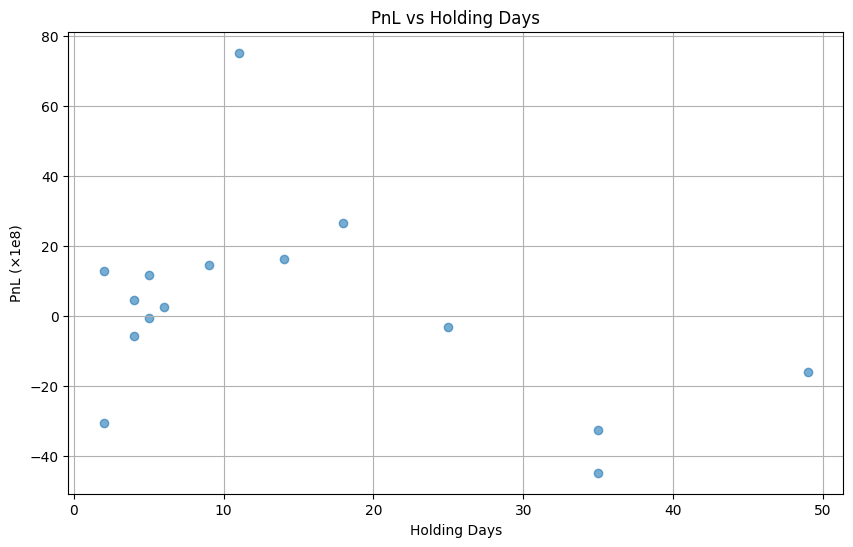

In [21]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,6))

plt.scatter(
    daily_pnl["holding_days"],
    daily_pnl["pnl"] / 1e8,
    alpha=0.6
)

plt.xlabel("Holding Days")
plt.ylabel("PnL (×1e8)")
plt.title("PnL vs Holding Days")
plt.grid(True)

plt.show()

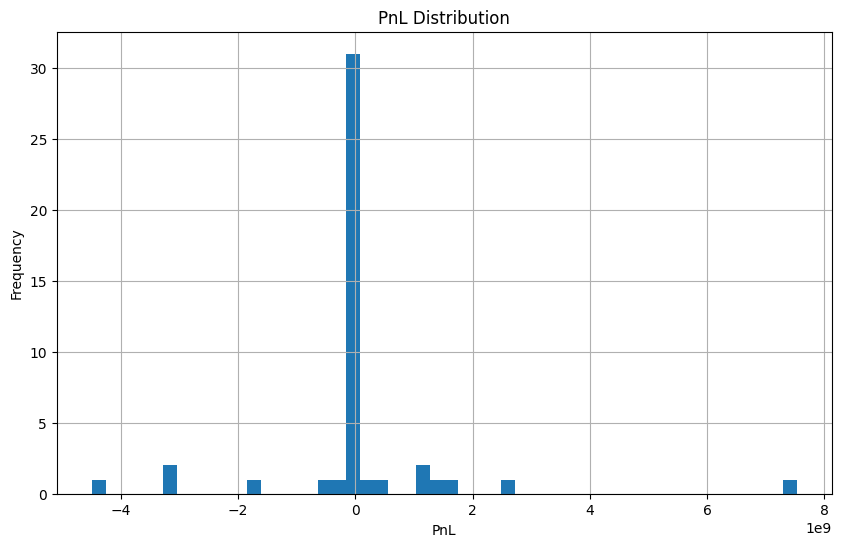

In [22]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,6))

plt.hist(closed_df["pnl"], bins=50)


plt.title("PnL Distribution")
plt.xlabel("PnL")
plt.ylabel("Frequency")

plt.grid(True)
plt.show()

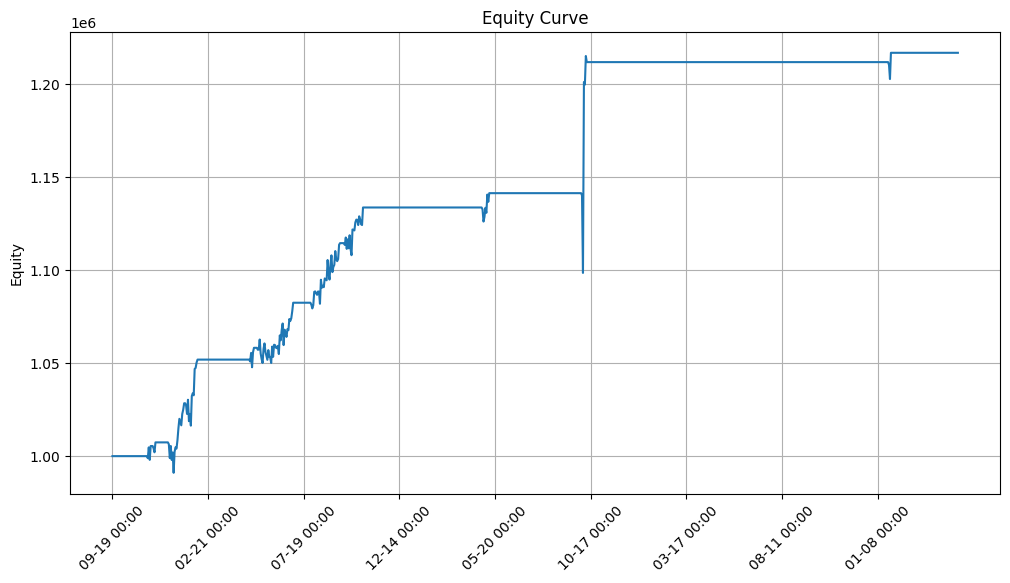

In [23]:
import pandas as pd
import matplotlib.pyplot as plt
results_df = pd.DataFrame(results)
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(range(len(results_df)), results_df["equity"])

# 每隔一些点显示一个timestamp
step = 100

ax.set_xticks(range(0, len(results_df), step))
ax.set_xticklabels(
    results_df["timestamp"].iloc[::step].dt.strftime("%m-%d %H:%M"),
    rotation=45
)

ax.set_title("Equity Curve")
ax.set_ylabel("Equity")

plt.grid(True)
plt.show()

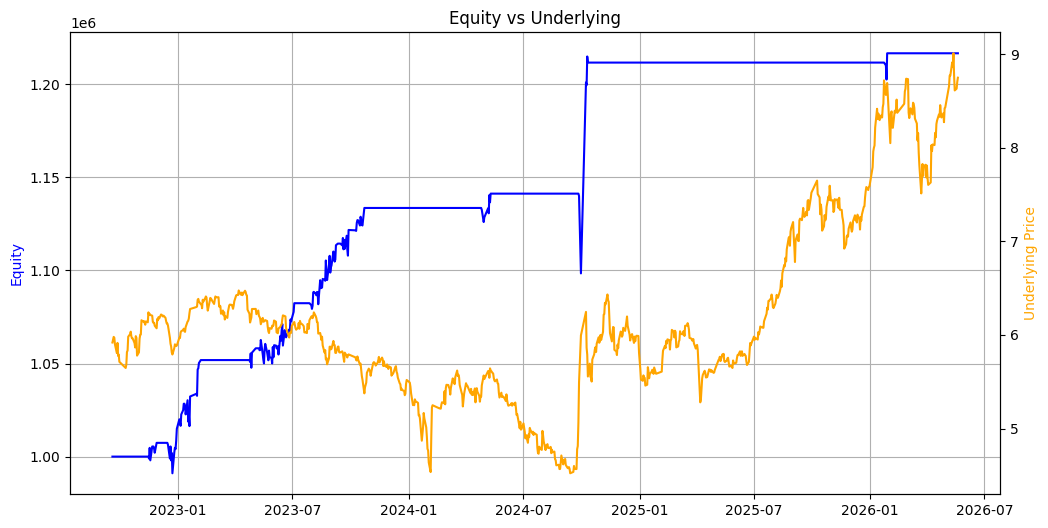

In [24]:
import pandas as pd
import matplotlib.pyplot as plt

# ========= 1. 数据准备 =========
results_df = pd.DataFrame(results)
results_df["timestamp"] = pd.to_datetime(results_df["timestamp"])

df_underlying = df_underlying.copy()
df_underlying["日期"] = pd.to_datetime(df_underlying["日期"])

# ========= 2. 用 equity 时间做裁剪 =========
start_time = results_df["timestamp"].iloc[0]
end_time = results_df["timestamp"].iloc[-1]

df_u = df_underlying[
    (df_underlying["日期"] >= start_time) &
    (df_underlying["日期"] <= end_time)
]

# ========= 3. 画图 =========
fig, ax1 = plt.subplots(figsize=(12, 6))

# equity
ax1.plot(results_df["timestamp"], results_df["equity"], label="Equity", color="blue")
ax1.set_ylabel("Equity", color="blue")

# underlying（第二轴）
ax2 = ax1.twinx()
ax2.plot(df_u["日期"], df_u["收盘价(元)"], label="Underlying", color="orange")
ax2.set_ylabel("Underlying Price", color="orange")

# ========= 4. 格式 =========
ax1.set_title("Equity vs Underlying")
ax1.grid(True)

plt.show()

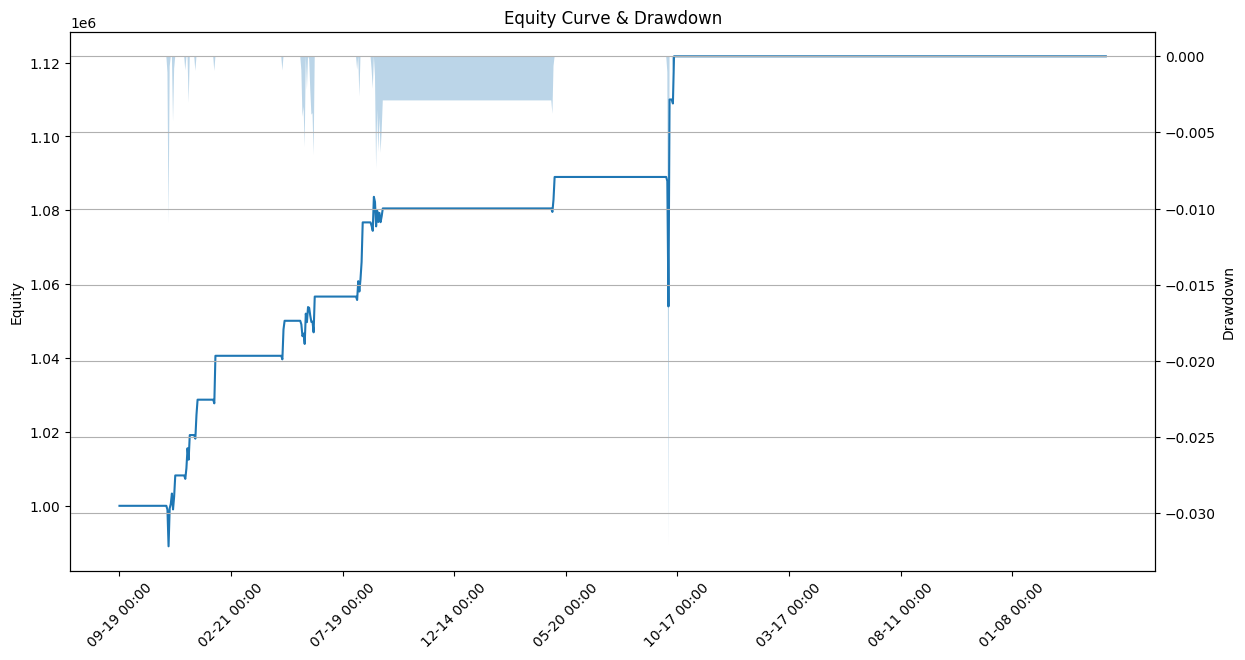

Annual Return: 3.18%
Annual Volatility: 3.82%
Max Drawdown: -3.22%
Sharpe Ratio: 0.83
Calmar Ratio: 0.99


In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# =========================
# Data
# =========================

results_df = pd.DataFrame(results)

results_df = results_df.sort_values("timestamp").reset_index(drop=True)

# =========================
# Return Series
# =========================

results_df["return"] = results_df["equity"].pct_change()

# =========================
# Drawdown
# =========================

results_df["cummax"] = results_df["equity"].cummax()

results_df["drawdown"] = (
    results_df["equity"] / results_df["cummax"] - 1
)

max_drawdown = results_df["drawdown"].min()

# =========================
# Annualized Return
# =========================

initial_equity = results_df["equity"].iloc[0]
final_equity = results_df["equity"].iloc[-1]

# total days
days = (
    results_df["timestamp"].iloc[-1]
    - results_df["timestamp"].iloc[0]
).days

annual_return = (
    final_equity / initial_equity
) ** (365 / days) - 1

# =========================
# Annualized Volatility
# =========================

# 日频:
annual_vol = (
    results_df["return"].std()
    * np.sqrt(252)
)

# =========================
# Sharpe Ratio
# =========================

risk_free_rate = 0

sharpe = (
    annual_return - risk_free_rate
) / annual_vol

# =========================
# Calmar Ratio
# =========================

calmar = annual_return / abs(max_drawdown)

# =========================
# Plot
# =========================

fig, ax1 = plt.subplots(figsize=(14, 7))

# Equity curve
ax1.plot(
    results_df.index,
    results_df["equity"],
    label="Equity"
)

ax1.set_ylabel("Equity")

# X axis labels
step = 100

ax1.set_xticks(range(0, len(results_df), step))

ax1.set_xticklabels(
    results_df["timestamp"]
    .iloc[::step]
    .dt.strftime("%m-%d %H:%M"),
    rotation=45
)

# =========================
# Drawdown axis
# =========================

ax2 = ax1.twinx()

ax2.fill_between(
    results_df.index,
    results_df["drawdown"],
    0,
    alpha=0.3,
    label="Drawdown"
)

ax2.set_ylabel("Drawdown")

# =========================
# Title
# =========================

ax1.set_title("Equity Curve & Drawdown")

plt.grid(True)

plt.show()

# =========================
# Metrics
# =========================

print(f"Annual Return: {annual_return:.2%}")

print(f"Annual Volatility: {annual_vol:.2%}")

print(f"Max Drawdown: {max_drawdown:.2%}")

print(f"Sharpe Ratio: {sharpe:.2f}")

print(f"Calmar Ratio: {calmar:.2f}")